In [27]:
from pathlib import Path
import sys
sys.dont_write_bytecode = True

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "lines.linewidth": 1.4,
    "axes.linewidth": 1,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
})

cwd = Path.cwd()
if (cwd / "utils.py").exists() and (cwd / "data").exists():
    notebook_dir = cwd
elif (cwd / "charge_stability_Leburton" / "utils.py").exists():
    notebook_dir = cwd / "charge_stability_Leburton"
else:
    notebook_dir = Path("charge_stability_Leburton").resolve()

if str(notebook_dir) not in sys.path:
    sys.path.insert(0, str(notebook_dir))

from utils import DataHelper

data_dir = notebook_dir / "data"


In [28]:
data_helper = DataHelper(
    data_dir=data_dir,
    results_filename="charge_stability.pkl",
    checkpoint_glob="charge_stability_runs_*.pkl",
)

checkpoint_path = data_helper.newest_checkpoint_path()
checkpoint_paths = [checkpoint_path] if checkpoint_path is not None else []
loaded_data = data_helper.load_data_with_checkpoints(
    default={"metadata": {}, "runs": [], "charge_stability": {}},
    checkpoint_paths=checkpoint_paths,
)

full_results = loaded_data["data"] or {"metadata": {}, "runs": [], "charge_stability": {}}
checkpoint_records = loaded_data["checkpoint_records"]
checkpoint_headers = [record for record in checkpoint_records if record.get("kind") == "header"]
checkpoint_run_records = [record for record in checkpoint_records if record.get("kind") == "run"]

metadata = dict(full_results.get("metadata", {}))
sweep_config = checkpoint_headers[-1].get("sweep_config", {}) if checkpoint_headers else {}
sweep_hash = checkpoint_headers[-1].get("sweep_hash") if checkpoint_headers else metadata.get("checkpoint_sweep_hash")

print(f"data directory: {data_dir}")
print(f"full results: {data_helper.results_path} ({'found' if data_helper.results_path.exists() else 'missing'})")
print(f"checkpoint: {checkpoint_path}")
print(f"checkpoint records: {len(checkpoint_records)} total, {len(checkpoint_run_records)} run(s)")
print(f"sweep hash: {sweep_hash}")


data directory: /home/leander/Documents/PhD/Research_Projects/QDots/charge_stability_Leburton/data
full results: /home/leander/Documents/PhD/Research_Projects/QDots/charge_stability_Leburton/data/charge_stability.pkl (found)
checkpoint: /home/leander/Documents/PhD/Research_Projects/QDots/charge_stability_Leburton/data/charge_stability_runs_476cd5197895.pkl
checkpoint records: 56 total, 55 run(s)
sweep hash: 476cd5197895


In [29]:
checkpoint_runs_by_grid_point = {
    (int(record["i"]), int(record["j"])): record["run"]
    for record in checkpoint_run_records
}

runs_by_grid_point = dict(checkpoint_runs_by_grid_point)

if not runs_by_grid_point:
    voltages = metadata.get("voltage_grid", sweep_config.get("voltages", []))
    voltage_grid = np.asarray(voltages, dtype=float)

    def grid_key_from_run(run):
        i = int(np.argmin(np.abs(voltage_grid - float(run["vL"]))))
        j = int(np.argmin(np.abs(voltage_grid - float(run["vR"]))))
        return i, j

    runs_by_grid_point = {
        grid_key_from_run(run): run
        for run in full_results.get("runs", [])
    }

runs = [runs_by_grid_point[key] for key in sorted(runs_by_grid_point)]
charge_stability = {
    "metadata": metadata,
    "sweep_config": sweep_config,
    "sweep_hash": sweep_hash,
    "runs": runs,
    "runs_by_grid_point": runs_by_grid_point,
}

print(f"loaded completed points: {len(runs_by_grid_point)}")
for key, run in sorted(runs_by_grid_point.items()):
    print(f"grid {key}: vL={1e3 * run['vL']:.3f} mV, vR={1e3 * run['vR']:.3f} mV, stable n={run.get('n_electrons')}")


loaded completed points: 55
grid (0, 0): vL=21.000 mV, vR=21.000 mV, stable n=1
grid (1, 0): vL=21.889 mV, vR=21.000 mV, stable n=2
grid (1, 1): vL=21.889 mV, vR=21.889 mV, stable n=2
grid (2, 0): vL=22.778 mV, vR=21.000 mV, stable n=2
grid (2, 1): vL=22.778 mV, vR=21.889 mV, stable n=2
grid (2, 2): vL=22.778 mV, vR=22.778 mV, stable n=2
grid (3, 0): vL=23.667 mV, vR=21.000 mV, stable n=2
grid (3, 1): vL=23.667 mV, vR=21.889 mV, stable n=2
grid (3, 2): vL=23.667 mV, vR=22.778 mV, stable n=2
grid (3, 3): vL=23.667 mV, vR=23.667 mV, stable n=2
grid (4, 0): vL=24.556 mV, vR=21.000 mV, stable n=2
grid (4, 1): vL=24.556 mV, vR=21.889 mV, stable n=2
grid (4, 2): vL=24.556 mV, vR=22.778 mV, stable n=2
grid (4, 3): vL=24.556 mV, vR=23.667 mV, stable n=2
grid (4, 4): vL=24.556 mV, vR=24.556 mV, stable n=2
grid (5, 0): vL=25.444 mV, vR=21.000 mV, stable n=2
grid (5, 1): vL=25.444 mV, vR=21.889 mV, stable n=2
grid (5, 2): vL=25.444 mV, vR=22.778 mV, stable n=2
grid (5, 3): vL=25.444 mV, vR=23.667

In [30]:
def result_with_stored_potential(runs_by_grid_point):
    for grid_key, run in sorted(runs_by_grid_point.items()):
        for n_electrons, result in sorted(run.get("points", {}).items(), key=lambda item: int(item[0])):
            potential = result.get("potential")
            if potential is not None:
                return grid_key, run, int(n_electrons), result, np.asarray(potential, dtype=float), "stored"
    return None


def analytic_potential_line(run, sweep_config, n_points=2001):
    L = float(sweep_config.get("L", 1.0))
    R = float(sweep_config["R"])
    d = float(sweep_config["d"])
    half_width = 10.0 * L
    x_centered = np.linspace(-half_width, half_width, n_points)
    v_l = float(run["vL"])
    v_r = float(run["vR"])
    potential = (
        -v_l * np.exp(-((x_centered + d / 2) ** 2) / (R**2))
        -v_r * np.exp(-((x_centered - d / 2) ** 2) / (R**2))
    )
    return np.column_stack([x_centered, potential])


entry = result_with_stored_potential(runs_by_grid_point)
if entry is None:
    if not runs:
        raise ValueError("No completed run was found in the checkpoint or full results.")
    if not {"L", "R", "d"}.issubset(sweep_config):
        raise ValueError("No stored potential found, and sweep_config is missing L/R/d for analytic reconstruction.")
    grid_key = sorted(runs_by_grid_point)[0]
    run = runs_by_grid_point[grid_key]
    n_electrons = run.get("n_electrons")
    result = None
    potential_data = analytic_potential_line(run, sweep_config)
    source = "analytic"
else:
    grid_key, run, n_electrons, result, potential_data, source = entry

x_raw = potential_data[:, 0]
potential = potential_data[:, 1]
if source == "stored":
    x = x_raw - 0.5 * (x_raw[0] + x_raw[-1])
else:
    x = x_raw

print(f"potential source: {source}")
print(f"grid point: {grid_key}")
print(f"voltages: vL={1e3 * run['vL']:.3f} mV, vR={1e3 * run['vR']:.3f} mV")
print(f"electron point: n={n_electrons}")
print(f"potential samples: {len(potential)}")


potential source: stored
grid point: (0, 0)
voltages: vL=21.000 mV, vR=21.000 mV
electron point: n=1
potential samples: 2001


In [31]:
voltages = metadata.get("voltage_grid", sweep_config.get("voltages", []))
voltage_grid_v = np.asarray(voltages, dtype=float)
if voltage_grid_v.size == 0 and runs_by_grid_point:
    voltage_grid_v = np.asarray(
        sorted({round(float(v), 15) for run in runs_by_grid_point.values() for v in (run["vL"], run["vR"])}),
        dtype=float,
    )
if voltage_grid_v.size == 0:
    raise ValueError("No voltage grid found in metadata, sweep_config, or loaded runs.")

voltage_grid_mV = voltage_grid_v * 1e3
n_grid = len(voltage_grid_v)


def empty_grid(fill=np.nan, dtype=float):
    return np.full((n_grid, n_grid), fill, dtype=dtype)


def mirror_lower_triangle(grid):
    mirrored = np.array(grid, copy=True)
    for i in range(n_grid):
        for j in range(i):
            if np.isfinite(mirrored[i, j]) and not np.isfinite(mirrored[j, i]):
                mirrored[j, i] = mirrored[i, j]
            elif np.isfinite(mirrored[j, i]) and not np.isfinite(mirrored[i, j]):
                mirrored[i, j] = mirrored[j, i]
    return mirrored


def result_for_n(run, n_electrons):
    points = run.get("points", {})
    return points.get(n_electrons, points.get(str(n_electrons)))


def energy_grid(n_electrons, mirror=True):
    grid = empty_grid()
    for (i, j), run in runs_by_grid_point.items():
        result = result_for_n(run, n_electrons)
        if result is not None and "energy" in result:
            grid[i, j] = float(result["energy"])
    return mirror_lower_triangle(grid) if mirror else grid


def stable_charge_grid(mirror=True):
    grid = empty_grid()
    for (i, j), run in runs_by_grid_point.items():
        if "n_electrons" in run:
            grid[i, j] = int(run["n_electrons"])
    return mirror_lower_triangle(grid) if mirror else grid


def imshow_grid(ax, grid, title, cmap="viridis", cbar_label=None, discrete=False):
    masked = np.ma.masked_invalid(grid)
    extent = [voltage_grid_mV[0], voltage_grid_mV[-1], voltage_grid_mV[0], voltage_grid_mV[-1]]
    kwargs = {"origin": "lower", "extent": extent, "aspect": "equal", "interpolation": "nearest", "cmap": cmap}
    if discrete and masked.count() > 0:
        values = np.unique(masked.compressed())
        boundaries = np.arange(values.min() - 0.5, values.max() + 1.5, 1)
        kwargs["norm"] = mpl.colors.BoundaryNorm(boundaries, plt.get_cmap(cmap).N)
    image = ax.imshow(masked.T, **kwargs)
    ax.set_xlabel(r"$V_L$ [mV]")
    ax.set_ylabel(r"$V_R$ [mV]")
    ax.set_title(title)
    cbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    if cbar_label:
        cbar.set_label(cbar_label)
    return image

print(f"voltage points: {n_grid}")
print(f"completed grid points: {len(runs_by_grid_point)}")


voltage points: 10
completed grid points: 55


In [35]:
charge_stability['metadata']

{'description': 'Charge stability sweep for a double quantum dot.',
 'length_scale_nm': 29.999999999999996,
 'effective_units_reference_energy': 2.024631645041782e-22,
 'coulomb_energy_effective_units': 2.944456941338863,
 'eV_error_tolerance': 1e-07,
 'e_conv_tolerance_effective_units': 7.913422858541441e-05,
 'voltage_grid': [0.021,
  0.02188888888888889,
  0.02277777777777778,
  0.02366666666666667,
  0.024555555555555556,
  0.025444444444444443,
  0.026333333333333334,
  0.02722222222222222,
  0.02811111111111111,
  0.029],
 'voltage_unit': 'V',
 'computed_voltage_region': 'vL >= vR; use symmetry for vL < vR',
 'energy_plot_electron_counts': [1, 2],
 'checkpoint_file': 'data/charge_stability_runs_476cd5197895.pkl',
 'checkpoint_sweep_hash': '476cd5197895',
 'full_save_interval_points': 50,
 'log_file': 'data/charge_stability.log'}

In [37]:
E0 = charge_stability['metadata']['effective_units_reference_energy']
e = e = 1.602176634e-19
eV_to_J = 1 * e

E0_to_eV = E0 / eV_to_J

l0 = charge_stability['metadata']['length_scale_nm']

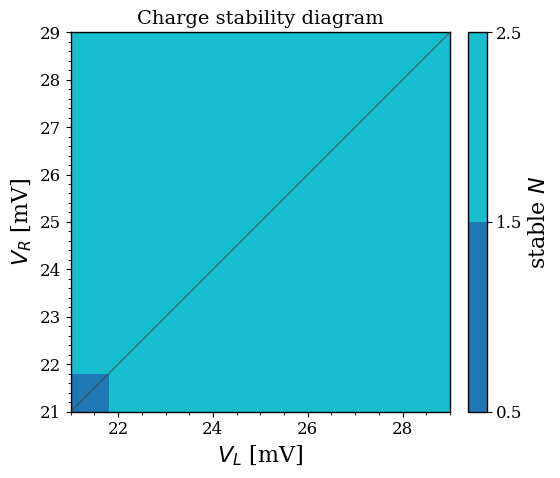

In [32]:
charge_grid = stable_charge_grid(mirror=True)

fig, ax = plt.subplots(figsize=(5.8, 5.0))
imshow_grid(ax, charge_grid, "Charge stability diagram", cmap="tab10", cbar_label=r"stable $N$", discrete=True)
ax.plot(voltage_grid_mV, voltage_grid_mV, color="0.25", lw=1, alpha=0.6)
fig.tight_layout()
plt.show()


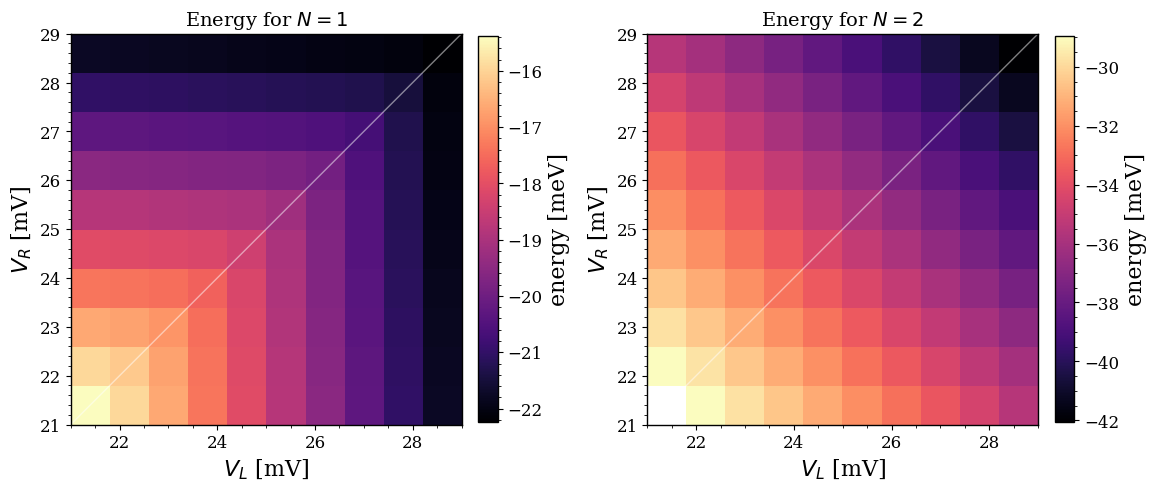

In [40]:
energy_grids = {n: energy_grid(n, mirror=True) for n in (1, 2)}

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8), constrained_layout=True)
for ax, n_electrons in zip(axes, (1, 2)):
    grid = energy_grids[n_electrons] * E0_to_eV * 1e3
    imshow_grid(
        ax,
        grid,
        rf"Energy for $N={n_electrons}$",
        cmap="magma",
        cbar_label="energy [meV]",
    )
    ax.plot(voltage_grid_mV, voltage_grid_mV, color="w", lw=1, alpha=0.5)
plt.show()


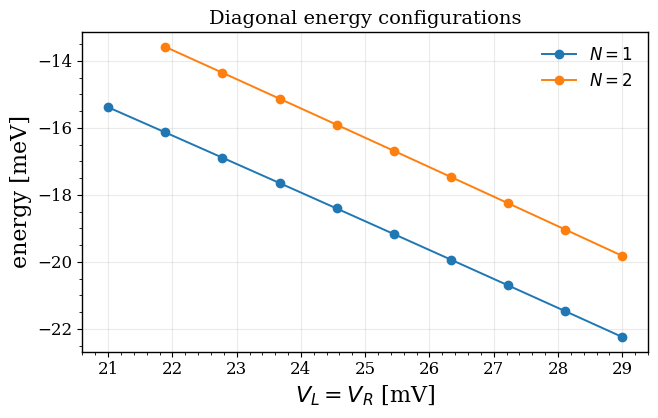

In [43]:
fig, ax = plt.subplots(figsize=(6.8, 4.4))
for n_electrons, grid in energy_grids.items():
    diagonal = np.diag(grid)
    mask = np.isfinite(diagonal)
    if n_electrons == 1:
        mu_N = diagonal[mask]
    else:
        diagonal_Nm1 = np.diag(energy_grids[n_electrons - 1])
        mu_N = diagonal[mask] - diagonal_Nm1[mask]
    ax.plot(voltage_grid_mV[mask], mu_N * E0_to_eV * 1e3, marker="o", label=rf"$N={n_electrons}$")

ax.set_xlabel(r"$V_L=V_R$ [mV]")
ax.set_ylabel("energy [meV]")
ax.set_title("Diagonal energy configurations")
ax.legend(frameon=False)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()
